In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install sklearn

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd

# Giả sử file có cột: "timestamp", "pm25"
df = pd.read_csv("/home/hoangnam/DataScience_Programming/IAQ Baqubah Teaching Hospital .csv")

# Convert ts to datetime
df['ts'] = pd.to_datetime(df['ts'], errors='coerce')

# Sort by time
df = df.sort_values('ts')

# Set datetime index (useful for resample / plotting)
df = df.set_index('ts')

df = df.resample("1min").mean()

df["PM2.5"] = df["PM2.5"].interpolate()

Base dataframe after resample/interpolate:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327587 entries, 2024-05-22 12:13:00 to 2025-01-04 23:59:00
Freq: min
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          327587 non-null  float64
 1   TVOC         327587 non-null  float64
 2   PM10         327587 non-null  float64
 3   PM2.5        327587 non-null  float64
 4   eCO2         327587 non-null  float64
 5   CO           327587 non-null  float64
 6   Air Quality  327587 non-null  float64
 7   LDR          327587 non-null  float64
 8   O3           327587 non-null  float64
 9   Temp         327587 non-null  float64
 10  Hum          327587 non-null  float64
dtypes: float64(11)
memory usage: 30.0 MB
None
Feature dataframe with target: (327557, 22)
X shape: (327377, 180, 21) | y shape: (327377,)
Train: (229163, 180, 21) Val: (49107, 180, 21) Test: (49107, 180, 21)
=== Naive baseline (future avg ≈ c

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 35s 36ms/step - loss: 2673.9434 - mae: 32.5246 - val_loss: 327.3701 - val_mae: 13.6433
Epoch 2/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 92.7753 - mae: 6.5484 - val_loss: 359.2715 - val_mae: 14.1659
Epoch 3/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 81.4905 - mae: 6.2045 - val_loss: 317.3361 - val_mae: 13.4180
Epoch 4/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 76.6075 - mae: 6.0567 - val_loss: 435.0751 - val_mae: 15.8003
Epoch 5/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 75.6486 - mae: 6.0119 - val_loss: 379.8818 - val_mae: 14.6879
Epoch 6/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 66.6138 - mae: 5.6436 - val_loss: 424.7846 - val_mae: 15.5729
Epoch 7/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - loss: 62.3858 - mae: 5.4943 - val_loss: 491.1108 - val_mae: 16.5389
Epoch 8/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 61.1641 - mae: 5.4251 - val_loss: 548.7225 - val_mae: 17.8167
1535/

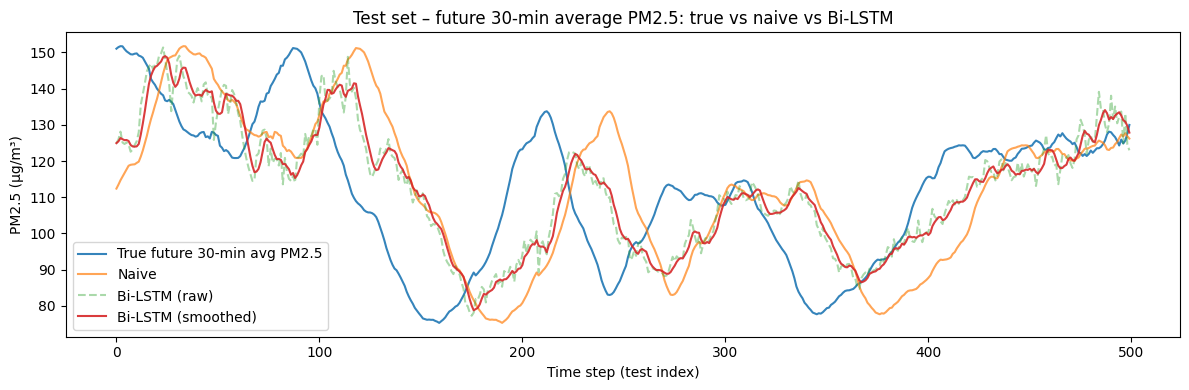

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. CONFIGURATION
# ============================================================

WINDOW_SIZE = 180         # ✔ dùng 3 giờ (180 phút) làm input
FUTURE_AVG_WINDOW = 30    # predict average over NEXT 30 minutes

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15        # rest for test


# ============================================================
# 2. df ALREADY LOADED – RESAMPLE & INTERPOLATE
# ============================================================

df = df.sort_index()

# 1-min frequency + interpolate
df = df.resample("1min").mean()
df = df.interpolate(method="time")

print("Base dataframe after resample/interpolate:")
print(df.info())


# ============================================================
# 3. FEATURE ENGINEERING
#    ✔ smoothing input
#    ✔ derivative features
# ============================================================

feat = df.copy()

# ---------- PM2.5 features ----------
feat["pm25_ma5"]    = feat["PM2.5"].rolling(5,  min_periods=1).mean()
feat["pm25_ma10"]   = feat["PM2.5"].rolling(10, min_periods=1).mean()
feat["pm25_ma30"]   = feat["PM2.5"].rolling(30, min_periods=1).mean()
feat["pm25_std5"]   = feat["PM2.5"].rolling(5,  min_periods=1).std().fillna(0.0)

# ✔ derivative feature
feat["pm25_diff1"]  = feat["PM2.5"].diff().fillna(0.0)
feat["pm25_diff2"]  = feat["PM2.5"].diff(2).fillna(0.0)

# ---------- CO2 features ----------
if "CO2" in feat.columns:
    feat["co2_raw"]    = feat["CO2"]
    feat["co2_ma10"]   = feat["CO2"].rolling(10, min_periods=1).mean()
    feat["co2_ma30"]   = feat["CO2"].rolling(30, min_periods=1).mean()
    feat["co2_diff1"]  = feat["CO2"].diff().fillna(0.0)

# ---------- Temp & Hum ----------
if "Temp" in feat.columns:
    feat["temp_raw"]   = feat["Temp"]
    feat["temp_ma10"]  = feat["Temp"].rolling(10, min_periods=1).mean()

if "Hum" in feat.columns:
    feat["hum_raw"]    = feat["Hum"]
    feat["hum_ma10"]   = feat["Hum"].rolling(10, min_periods=1).mean()

# ---------- Other raw sensors (optional) ----------
for col in ["TVOC", "CO", "Air Quality", "LDR", "O3", "PM10", "eCO2"]:
    if col in feat.columns:
        feat[col.lower().replace(" ", "_") + "_raw"] = feat[col]

# (optional) drop original columns that we no longer need directly
base_cols = ["PM2.5", "CO2", "TVOC", "CO", "Air Quality",
             "LDR", "O3", "Temp", "Hum", "PM10", "eCO2"]
for c in base_cols:
    if c in feat.columns:
        feat = feat.drop(columns=c)


# ============================================================
# 4. DEFINE TARGET: FUTURE 30-MINUTE AVERAGE (DIRECT)
#    ✔ không dùng recursive prediction
# ============================================================

pm25_future_avg30 = (
    df["PM2.5"]
    .rolling(FUTURE_AVG_WINDOW, min_periods=1)
    .mean()
    .shift(-FUTURE_AVG_WINDOW)  # mean(t+1..t+30)
)

feat["target_pm25_avg30"] = pm25_future_avg30

# bỏ các dòng target NaN (cuối series)
feat = feat.dropna()
print("Feature dataframe with target:", feat.shape)


# ============================================================
# 5. BUILD SUPERVISED WINDOWS
# ============================================================

def create_supervised_windows(dataframe, feature_cols, target_col, window_size):
    """
    X: past `window_size` steps of features
    y: target at current time step (future 30-min average đã encode sẵn)
    """
    values  = dataframe[feature_cols].values
    targets = dataframe[target_col].values

    X_list, y_list = [], []
    n_total = len(dataframe)

    for end_idx in range(window_size, n_total):
        start_idx = end_idx - window_size
        X_list.append(values[start_idx:end_idx])
        y_list.append(targets[end_idx])

    X = np.array(X_list)
    y = np.array(y_list)
    return X, y


feature_cols = [c for c in feat.columns if c != "target_pm25_avg30"]

X, y = create_supervised_windows(
    feat,
    feature_cols=feature_cols,
    target_col="target_pm25_avg30",
    window_size=WINDOW_SIZE,
)

print("X shape:", X.shape, "| y shape:", y.shape)


# ============================================================
# 6. TRAIN/VAL/TEST SPLIT (TIME-BASED)
# ============================================================

n_samples = len(X)
train_end = int(n_samples * TRAIN_RATIO)
val_end   = int(n_samples * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


# ============================================================
# 7. SCALE FEATURES (fit on train only)
# ============================================================

num_features = X_train.shape[-1]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, num_features)
X_val_2d   = X_val.reshape(-1, num_features)
X_test_2d  = X_test.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)


# ============================================================
# 8. NAIVE BASELINE
# ============================================================

pm25_ma30_col = "pm25_ma30"
if pm25_ma30_col not in feature_cols:
    raise ValueError("pm25_ma30 feature not found; check feature engineering.")

pm25_ma30_idx = feature_cols.index(pm25_ma30_col)

# last pm25_ma30 in window = prediction
y_pred_naive = X_test[:, -1, pm25_ma30_idx]

mae_naive  = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive   = r2_score(y_test, y_pred_naive)

print("=== Naive baseline (future avg ≈ current 30-min avg) ===")
print(f"MAE  : {mae_naive:.4f} µg/m³")
print(f"RMSE : {rmse_naive:.4f} µg/m³")
print(f"R²   : {r2_naive:.4f}")


# ============================================================
# 9. BI-LSTM MODEL
#    ✔ Bi-LSTM + Dense
# ============================================================

model = Sequential([
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(WINDOW_SIZE, num_features)
    ),
    LSTM(32),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)   # future 30-min average PM2.5
])

model.compile(
    loss="mse",
    optimizer="adam",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


# ------------------------------------------------------------
# Evaluate on test set – raw predictions
# ------------------------------------------------------------
y_pred_lstm = model.predict(X_test_scaled).ravel()

mae_lstm_raw  = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm_raw = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm_raw   = r2_score(y_test, y_pred_lstm)
mbe_lstm_raw  = np.mean(y_pred_lstm - y_test)

print("\n=== Bi-LSTM (RAW) – future 30-min avg PM2.5 ===")
print(f"MAE  : {mae_lstm_raw:.4f} µg/m³")
print(f"RMSE : {rmse_lstm_raw:.4f} µg/m³")
print(f"R²   : {r2_lstm_raw:.4f}")
print(f"MBE  : {mbe_lstm_raw:.4f} µg/m³")


# ============================================================
# 10. SMOOTHING OUTPUT (POST-PROCESS)
#     ✔ giảm rung / noise cho đường dự đoán
# ============================================================

pred_series = pd.Series(y_pred_lstm)
y_pred_lstm_smooth = pred_series.rolling(window=5, min_periods=1).mean().values

mae_lstm_s  = mean_absolute_error(y_test, y_pred_lstm_smooth)
rmse_lstm_s = np.sqrt(mean_squared_error(y_test, y_pred_lstm_smooth))
r2_lstm_s   = r2_score(y_test, y_pred_lstm_smooth)
mbe_lstm_s  = np.mean(y_pred_lstm_smooth - y_test)

print("\n=== Bi-LSTM (SMOOTHED OUTPUT, win=5) ===")
print(f"MAE  : {mae_lstm_s:.4f} µg/m³")
print(f"RMSE : {rmse_lstm_s:.4f} µg/m³")
print(f"R²   : {r2_lstm_s:.4f}")
print(f"MBE  : {mbe_lstm_s:.4f} µg/m³")


# ============================================================
# 11. VISUALIZE – TRUE vs NAIVE vs LSTM (SMOOTHED)
# ============================================================

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500   # slice for clearer plot; adjust as you like

plt.plot(y_test[idx0:idx1], label="True future 30-min avg PM2.5", alpha=0.9)
plt.plot(y_pred_naive[idx0:idx1], label="Naive", alpha=0.7)
plt.plot(y_pred_lstm[idx0:idx1], label="Bi-LSTM (raw)", alpha=0.4, linestyle="--")
plt.plot(y_pred_lstm_smooth[idx0:idx1], label="Bi-LSTM (smoothed)", alpha=0.9)

plt.legend()
plt.title("Test set – future 30-min average PM2.5: true vs naive vs Bi-LSTM")
plt.xlabel("Time step (test index)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


Best shift for LSTM: -23
Best MAE: 15.4589


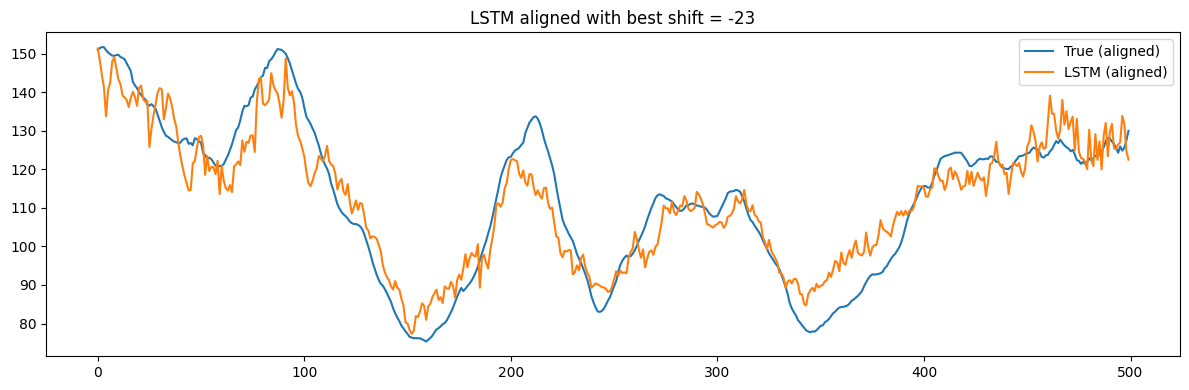

In [11]:
result_lstm = find_best_shift(y_test, y_pred_lstm, max_shift=60, metric="mae")
print("Best shift for LSTM:", result_lstm["best_shift"])
print(f"Best {result_lstm['metric'].upper()}: {result_lstm['best_score']:.4f}")
yt_lstm_aligned = result_lstm["y_true_aligned"]
yp_lstm_aligned = result_lstm["y_pred_aligned"]

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500  # sau khi align có thể ngắn hơn, nhớ check len()
plt.plot(yt_lstm_aligned[idx0:idx1], label="True (aligned)")
plt.plot(yp_lstm_aligned[idx0:idx1], label="LSTM (aligned)")
plt.legend()
plt.title(f"LSTM aligned with best shift = {result_lstm['best_shift']}")
plt.tight_layout()
plt.show()

2025-11-27 06:29:09.525793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764224949.752217      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764224949.813707      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Base dataframe after resample/interpolate:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327587 entries, 2024-05-22 12:13:00 to 2025-01-04 23:59:00
Freq: min
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          327587 non-null  float64
 1   TVOC         327587 non-null  float64
 2   PM10         327587 non-null  float64
 3   PM2.5        327587 non-null  float64
 4   eCO2         327587 non-null  float64
 5   CO           327587 non-null  float64
 6   Air Quality  327587 non-null  float64
 7   LDR          327587 non-null  float64
 8   O3           327587 non-null  float64
 9   Temp         327587 non-null  float64
 10  Hum          327587 non-null  float64
dtypes: float64(11)
memory usage: 30.0 MB
None
Feature dataframe with target: (327557, 19)
X shape: (327497, 60, 18) | y shape: (327497,)
Train: (229247, 60, 18) Val: (49125, 60, 18) Test: (49125, 60, 18)
=== Naive baseline (future avg ≈ curre

I0000 00:00:1764224973.401566      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764224973.402125      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1764224979.676954     152 cuda_dnn.cc:529] Loaded cuDNN version 90300


896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 4554.5225 - mae: 51.7912 - val_loss: 526.4133 - val_mae: 16.4346
Epoch 2/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 129.9551 - mae: 7.2358 - val_loss: 321.0846 - val_mae: 13.3887
Epoch 3/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 105.2897 - mae: 6.7431 - val_loss: 311.7523 - val_mae: 13.5118
Epoch 4/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 94.4422 - mae: 6.5520 - val_loss: 331.3973 - val_mae: 13.7855
Epoch 5/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 84.4869 - mae: 6.2997 - val_loss: 332.5094 - val_mae: 13.8588
Epoch 6/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 77.9241 - mae: 6.0919 - val_loss: 382.5296 - val_mae: 14.8981
Epoch 7/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 72.3611 - mae: 5.9017 - val_loss: 430.2014 - val_mae: 15.7214
Epoch 8/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 68.3283 - mae: 5.7449 - val_loss: 451.5671 - val_mae: 16.4671
1536/1536 ━━━━━━━━━━━━━━━━━━

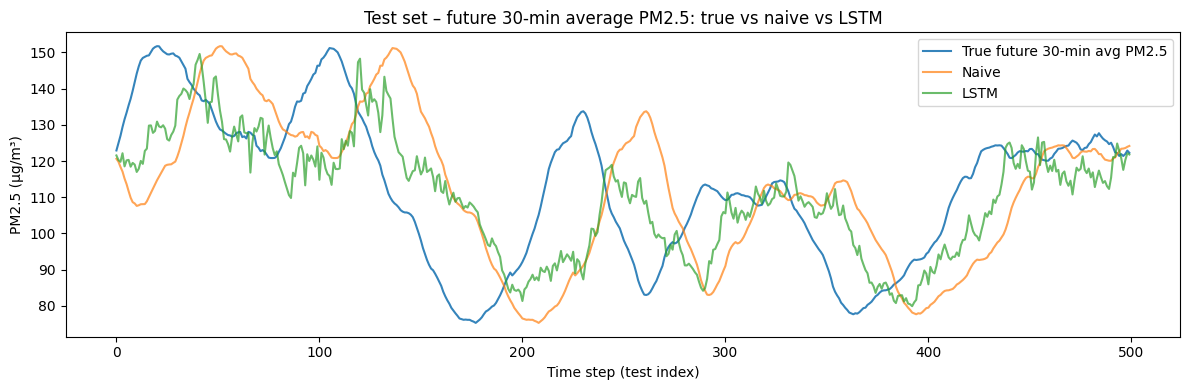

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. CONFIGURATION
# ============================================================

WINDOW_SIZE = 60          # use last 60 minutes as input
FUTURE_AVG_WINDOW = 30    # predict average over NEXT 30 minutes

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15        # rest for test


# ============================================================
# 2. ASSUME df ALREADY LOADED
#    df is indexed by timestamp with columns incl. "PM2.5"
# ============================================================

df = df.sort_index()

# Make sure we have 1-min frequency and interpolate missing timestamps
df = df.resample("1min").mean()
df = df.interpolate(method="time")

print("Base dataframe after resample/interpolate:")
print(df.info())


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

feat = df.copy()

# ---------- PM2.5 features ----------
# ✅ removed pm25_raw from input (we only use smoothed / derived features)
feat["pm25_ma5"]    = feat["PM2.5"].rolling(5,  min_periods=1).mean()
feat["pm25_ma10"]   = feat["PM2.5"].rolling(10, min_periods=1).mean()
feat["pm25_ma30"]   = feat["PM2.5"].rolling(30, min_periods=1).mean()
feat["pm25_std5"]   = feat["PM2.5"].rolling(5,  min_periods=1).std().fillna(0.0)
feat["pm25_diff1"]  = feat["PM2.5"].diff().fillna(0.0)

# ---------- CO2 features ----------
if "CO2" in feat.columns:
    feat["co2_raw"]    = feat["CO2"]
    feat["co2_ma10"]   = feat["CO2"].rolling(10, min_periods=1).mean()
    feat["co2_ma30"]   = feat["CO2"].rolling(30, min_periods=1).mean()
    feat["co2_diff1"]  = feat["CO2"].diff().fillna(0.0)

# ---------- Temp & Hum ----------
if "Temp" in feat.columns:
    feat["temp_raw"]   = feat["Temp"]
    feat["temp_ma10"]  = feat["Temp"].rolling(10, min_periods=1).mean()

if "Hum" in feat.columns:
    feat["hum_raw"]    = feat["Hum"]
    feat["hum_ma10"]   = feat["Hum"].rolling(10, min_periods=1).mean()

# ---------- Other raw sensors (optional) ----------
for col in ["TVOC", "CO", "Air Quality", "O3", "LDR"]:
    if col in feat.columns:
        feat[col.lower().replace(" ", "_") + "_raw"] = feat[col]

# (optional) drop original columns that we no longer need directly
base_cols = ["PM2.5", "CO2", "TVOC", "CO", "Air Quality", "LDR", "O3", "Temp", "Hum", "PM10", "eCO2"]
for c in base_cols:
    if c in feat.columns:
        feat = feat.drop(columns=c)


# ============================================================
# 4. DEFINE TARGET: FUTURE 30-MINUTE AVERAGE
# ============================================================

# We want: average PM2.5 over the next 30 minutes
# i.e. mean of PM2.5(t+1 ... t+30)
pm25_future_avg30 = (
    df["PM2.5"]
    .rolling(FUTURE_AVG_WINDOW, min_periods=1)
    .mean()
    .shift(-FUTURE_AVG_WINDOW)  # shift backwards so current row points to future avg
)

feat["target_pm25_avg30"] = pm25_future_avg30

# Drop rows where target is NaN (near the end)
feat = feat.dropna()
print("Feature dataframe with target:", feat.shape)


# ============================================================
# 5. BUILD SUPERVISED WINDOWS
# ============================================================

def create_supervised_windows(dataframe, feature_cols, target_col, window_size):
    """
    Build supervised samples:
    - X: past `window_size` steps of features
    - y: target at current time step (future 30-min average already encoded)
    """
    values = dataframe[feature_cols].values
    targets = dataframe[target_col].values

    X_list, y_list = [], []
    n_total = len(dataframe)

    for end_idx in range(window_size, n_total):
        start_idx = end_idx - window_size
        X_list.append(values[start_idx:end_idx])
        y_list.append(targets[end_idx])

    X = np.array(X_list)  # (samples, window_size, num_features)
    y = np.array(y_list)  # (samples,)
    return X, y


feature_cols = [c for c in feat.columns if c != "target_pm25_avg30"]

X, y = create_supervised_windows(
    feat,
    feature_cols=feature_cols,
    target_col="target_pm25_avg30",
    window_size=WINDOW_SIZE,
)

print("X shape:", X.shape, "| y shape:", y.shape)


# ============================================================
# 6. TRAIN/VAL/TEST SPLIT (TIME-BASED)
# ============================================================

n_samples = len(X)
train_end = int(n_samples * TRAIN_RATIO)
val_end   = int(n_samples * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


# ============================================================
# 7. SCALE FEATURES (fit on train only)
# ============================================================

num_features = X_train.shape[-1]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, num_features)
X_val_2d   = X_val.reshape(-1, num_features)
X_test_2d  = X_test.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)


# ============================================================
# 8. NAIVE BASELINE:
#    predict future 30-min avg = current 30-min avg (last step in window)
# ============================================================

pm25_ma30_col = "pm25_ma30"
if pm25_ma30_col not in feature_cols:
    raise ValueError("pm25_ma30 feature not found; check feature engineering.")

pm25_ma30_idx = feature_cols.index(pm25_ma30_col)

# last pm25_ma30 in the window as prediction
y_pred_naive = X_test[:, -1, pm25_ma30_idx]

mae_naive  = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive   = r2_score(y_test, y_pred_naive)

print("=== Naive baseline (future avg ≈ current 30-min avg) ===")
print(f"MAE  : {mae_naive:.4f} µg/m³")
print(f"RMSE : {rmse_naive:.4f} µg/m³")
print(f"R²   : {r2_naive:.4f}")


# ============================================================
# 9. LSTM MODEL FOR FUTURE 30-MIN AVERAGE
# ============================================================

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features)),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)   # future 30-min average PM2.5
])

model.compile(
    loss="mse",
    optimizer="adam",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# Evaluate on test set
# ------------------------------------------------------------
y_pred_lstm = model.predict(X_test_scaled).ravel()

mae_lstm  = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm   = r2_score(y_test, y_pred_lstm)

print("\n=== LSTM baseline (future 30-min avg PM2.5) ===")
print(f"MAE  : {mae_lstm:.4f} µg/m³")
print(f"RMSE : {rmse_lstm:.4f} µg/m³")
print(f"R²   : {r2_lstm:.4f}")

# Optional: Mean Bias Error (systematic over/under prediction)
mbe_lstm = np.mean(y_pred_lstm - y_test)
print(f"MBE  : {mbe_lstm:.4f} µg/m³")


# ============================================================
# 10. VISUALIZE FUTURE AVERAGE PREDICTION
# ============================================================

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500   # slice for clearer plot; adjust as you like
plt.plot(y_test[idx0:idx1], label="True future 30-min avg PM2.5", alpha=0.9)
plt.plot(y_pred_naive[idx0:idx1], label="Naive", alpha=0.7)
plt.plot(y_pred_lstm[idx0:idx1], label="LSTM", alpha=0.7)
plt.legend()
plt.title("Test set – future 30-min average PM2.5: true vs naive vs LSTM")
plt.xlabel("Time step (test index)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


In [ ]:
y_pred_lstm = model.predict(X_test_scaled).ravel()

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def find_best_shift(y_true, y_pred, max_shift=60, metric="mae"):
    """
    Tìm shift tốt nhất (âm/dương) để align y_pred với y_true.

    shift > 0  : dịch y_pred sang TRÁI (dự đoán đến sớm hơn)
    shift < 0  : dịch y_pred sang PHẢI (dự đoán đến muộn hơn)
    """
    assert len(y_true) == len(y_pred), "y_true và y_pred phải cùng độ dài"

    best_shift = 0
    best_score = np.inf
    best_y_true_aligned = None
    best_y_pred_aligned = None

    for shift in range(-max_shift, max_shift + 1):
        if shift > 0:
            # bỏ bớt phần đầu của y_true, bỏ bớt phần cuối của y_pred
            yt = y_true[shift:]
            yp = y_pred[:-shift]
        elif shift < 0:
            s = -shift
            # bỏ bớt phần cuối của y_true, bỏ bớt phần đầu của y_pred
            yt = y_true[:-s]
            yp = y_pred[s:]
        else:
            yt = y_true
            yp = y_pred

        if metric == "mae":
            score = mean_absolute_error(yt, yp)
        elif metric == "rmse":
            score = np.sqrt(mean_squared_error(yt, yp))
        else:
            raise ValueError("metric phải là 'mae' hoặc 'rmse'.")

        if score < best_score:
            best_score = score
            best_shift = shift
            best_y_true_aligned = yt
            best_y_pred_aligned = yp

    return {
        "best_shift": best_shift,
        "best_score": best_score,
        "y_true_aligned": best_y_true_aligned,
        "y_pred_aligned": best_y_pred_aligned,
        "metric": metric,
    }


In [7]:
y_pred_lstm = model.predict(X_test_scaled).ravel()


1536/1536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [8]:
result_lstm = find_best_shift(y_test, y_pred_lstm, max_shift=60, metric="mae")
print("Best shift for LSTM:", result_lstm["best_shift"])
print(f"Best {result_lstm['metric'].upper()}: {result_lstm['best_score']:.4f}")


Best shift for LSTM: -26
Best MAE: 11.3613


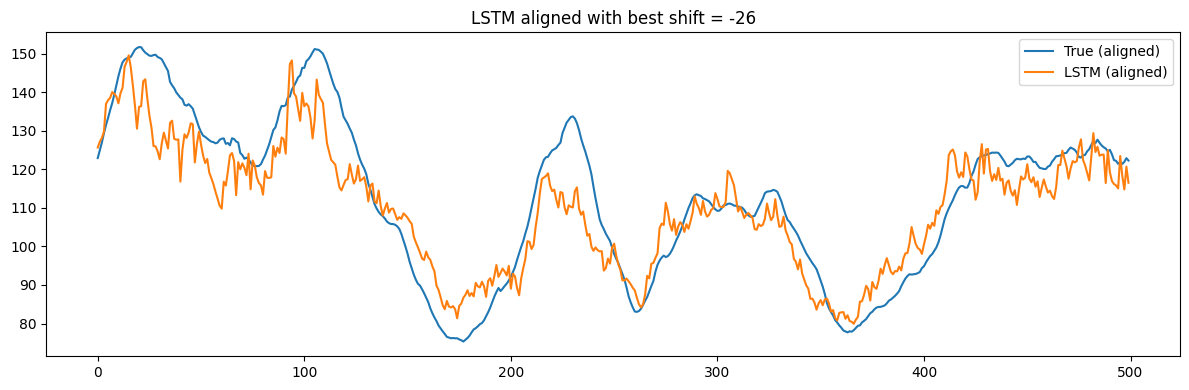

In [9]:
yt_lstm_aligned = result_lstm["y_true_aligned"]
yp_lstm_aligned = result_lstm["y_pred_aligned"]

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500  # sau khi align có thể ngắn hơn, nhớ check len()
plt.plot(yt_lstm_aligned[idx0:idx1], label="True (aligned)")
plt.plot(yp_lstm_aligned[idx0:idx1], label="LSTM (aligned)")
plt.legend()
plt.title(f"LSTM aligned with best shift = {result_lstm['best_shift']}")
plt.tight_layout()
plt.show()


Base dataframe after resample/interpolate:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327587 entries, 2024-05-22 12:13:00 to 2025-01-04 23:59:00
Freq: min
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          327587 non-null  float64
 1   TVOC         327587 non-null  float64
 2   PM10         327587 non-null  float64
 3   PM2.5        327587 non-null  float64
 4   eCO2         327587 non-null  float64
 5   CO           327587 non-null  float64
 6   Air Quality  327587 non-null  float64
 7   LDR          327587 non-null  float64
 8   O3           327587 non-null  float64
 9   Temp         327587 non-null  float64
 10  Hum          327587 non-null  float64
dtypes: float64(11)
memory usage: 30.0 MB
None
Feature dataframe with target: (327557, 12)
X shape: (327497, 60, 11) | y shape: (327497,)
Train: (229247, 60, 11) Val: (49125, 60, 11) Test: (49125, 60, 11)
=== Naive baseline (future avg ≈ curre

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 4991.5049 - mae: 55.2659 - val_loss: 654.4783 - val_mae: 18.1676
Epoch 2/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 143.1251 - mae: 7.5135 - val_loss: 363.3635 - val_mae: 13.9992
Epoch 3/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 108.1076 - mae: 6.7729 - val_loss: 345.8556 - val_mae: 13.9201
Epoch 4/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 96.1622 - mae: 6.5597 - val_loss: 328.4481 - val_mae: 13.6364
Epoch 5/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 88.6005 - mae: 6.4357 - val_loss: 331.7272 - val_mae: 13.7419
Epoch 6/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 82.3059 - mae: 6.2547 - val_loss: 340.8462 - val_mae: 13.9034
Epoch 7/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 75.9484 - mae: 6.0563 - val_loss: 378.6199 - val_mae: 14.5909
Epoch 8/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 73.7168 - mae: 5.9830 - val_loss: 368.0639 - val_mae: 14.4678
Epoch 9/50
896/89

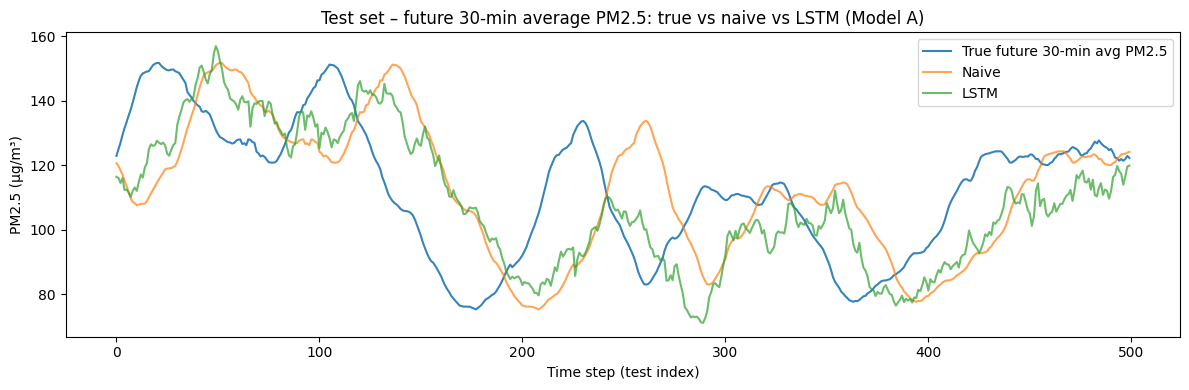

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. CONFIGURATION
# ============================================================

WINDOW_SIZE = 60          # use last 60 minutes as input
FUTURE_AVG_WINDOW = 30    # predict average over NEXT 30 minutes

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15        # rest for test


# ============================================================
# 2. ASSUME df ALREADY LOADED
#    df is indexed by timestamp with columns incl. "PM2.5"
# ============================================================

df = df.sort_index()

# Make sure we have 1-min frequency and interpolate missing timestamps
df = df.resample("1min").mean()
df = df.interpolate(method="time")

print("Base dataframe after resample/interpolate:")
print(df.info())


# ============================================================
# 3. FEATURE ENGINEERING (MODEL A: ONLY PM2.5 FEATURES)
# ============================================================

feat = pd.DataFrame(index=df.index)

pm25 = df["PM2.5"]

# --- Raw PM2.5 (giữ lại để model vẫn "nhìn" được giá trị gốc) ---
feat["pm25_raw"] = pm25

# --- Smoothed versions (giảm nhiễu 1-phút) ---
feat["pm25_smooth5"]  = pm25.rolling(5,  min_periods=1).mean()   # trung bình 5 phút
feat["pm25_smooth10"] = pm25.rolling(10, min_periods=1).mean()   # trung bình 10 phút
feat["pm25_ma30"]     = pm25.rolling(30, min_periods=1).mean()   # trung bình 30 phút (slow trend)

# --- Local volatility (độ lệch chuẩn sau smoothing) ---
feat["pm25_std5"] = pm25.rolling(5, min_periods=1).std().fillna(0.0)

# --- Trend (thay cho pm25_diff1 rất nhiễu) ---
# sử dụng diff trên chuỗi đã làm mượt → phản ánh xu hướng thay đổi chứ không phải noise
feat["pm25_trend10"] = feat["pm25_smooth10"].diff().fillna(0.0)   # tốc độ đổi trong ~10 phút
feat["pm25_trend30"] = feat["pm25_ma30"].diff().fillna(0.0)       # trend dài hơn

# --- Explicit lags (áp trên chuỗi đã làm mượt để tránh học noise) ---
feat["pm25_lag10"] = feat["pm25_smooth10"].shift(10).bfill()
feat["pm25_lag20"] = feat["pm25_smooth10"].shift(20).bfill()

# (optional) time features: hour of day (chu kỳ ngày)
feat["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24.0)
feat["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24.0)



# ============================================================
# 4. DEFINE TARGET: FUTURE 30-MINUTE AVERAGE (GIỮ NHƯ CŨ)
# ============================================================

pm25_future_avg30 = (
    df["PM2.5"]
    .rolling(FUTURE_AVG_WINDOW, min_periods=1)
    .mean()
    .shift(-FUTURE_AVG_WINDOW)  # shift backwards so current row points to future avg
)

feat["target_pm25_avg30"] = pm25_future_avg30

# Drop rows where target is NaN (near the end)
feat = feat.dropna()
print("Feature dataframe with target:", feat.shape)


# ============================================================
# 5. BUILD SUPERVISED WINDOWS
# ============================================================

def create_supervised_windows(dataframe, feature_cols, target_col, window_size):
    values = dataframe[feature_cols].values
    targets = dataframe[target_col].values

    X_list, y_list = [], []
    n_total = len(dataframe)

    for end_idx in range(window_size, n_total):
        start_idx = end_idx - window_size
        X_list.append(values[start_idx:end_idx])
        y_list.append(targets[end_idx])

    X = np.array(X_list)  # (samples, window_size, num_features)
    y = np.array(y_list)  # (samples,)
    return X, y


feature_cols = [c for c in feat.columns if c != "target_pm25_avg30"]

X, y = create_supervised_windows(
    feat,
    feature_cols=feature_cols,
    target_col="target_pm25_avg30",
    window_size=WINDOW_SIZE,
)

print("X shape:", X.shape, "| y shape:", y.shape)


# ============================================================
# 6. TRAIN/VAL/TEST SPLIT (TIME-BASED)
# ============================================================

n_samples = len(X)
train_end = int(n_samples * TRAIN_RATIO)
val_end   = int(n_samples * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


# ============================================================
# 7. SCALE FEATURES (fit on train only)
# ============================================================

num_features = X_train.shape[-1]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, num_features)
X_val_2d   = X_val.reshape(-1, num_features)
X_test_2d  = X_test.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)


# ============================================================
# 8. NAIVE BASELINE (PM2.5 ONLY)
# ============================================================

pm25_ma30_col = "pm25_ma30"
if pm25_ma30_col not in feature_cols:
    raise ValueError("pm25_ma30 feature not found; check feature engineering.")

pm25_ma30_idx = feature_cols.index(pm25_ma30_col)

y_pred_naive = X_test[:, -1, pm25_ma30_idx]

mae_naive  = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive   = r2_score(y_test, y_pred_naive)

print("=== Naive baseline (future avg ≈ current 30-min avg) ===")
print(f"MAE  : {mae_naive:.4f} µg/m³")
print(f"RMSE : {rmse_naive:.4f} µg/m³")
print(f"R²   : {r2_naive:.4f}")


# ============================================================
# 9. LSTM MODEL FOR FUTURE 30-MIN AVERAGE (MODEL A)
# ============================================================

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features)),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)   # future 30-min average PM2.5
])

model.compile(
    loss="mse",
    optimizer="adam",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# Evaluate on test set
# ------------------------------------------------------------
y_pred_lstm = model.predict(X_test_scaled).ravel()

mae_lstm  = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm   = r2_score(y_test, y_pred_lstm)

print("\n=== LSTM Model A (future 30-min avg PM2.5) ===")
print(f"MAE  : {mae_lstm:.4f} µg/m³")
print(f"RMSE : {rmse_lstm:.4f} µg/m³")
print(f"R²   : {r2_lstm:.4f}")
mbe_lstm = np.mean(y_pred_lstm - y_test)
print(f"MBE  : {mbe_lstm:.4f} µg/m³")


# ============================================================
# 10. FUNCTION TO CHECK LAG (BEST SHIFT)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def find_best_shift(y_true, y_pred, max_shift=60, metric="mae"):
    assert len(y_true) == len(y_pred)

    best_shift = 0
    best_score = np.inf
    for shift in range(-max_shift, max_shift + 1):
        if shift > 0:
            yt = y_true[shift:]
            yp = y_pred[:-shift]
        elif shift < 0:
            s = -shift
            yt = y_true[:-s]
            yp = y_pred[s:]
        else:
            yt = y_true
            yp = y_pred

        if metric == "mae":
            score = mean_absolute_error(yt, yp)
        else:
            score = np.sqrt(mean_squared_error(yt, yp))

        if score < best_score:
            best_score = score
            best_shift = shift

    return best_shift, best_score

best_shift_lstm, best_mae_shift = find_best_shift(y_test, y_pred_lstm, max_shift=60, metric="mae")
print(f"\nBest shift for LSTM (Model A): {best_shift_lstm} steps")
print(f"MAE with best shift: {best_mae_shift:.4f} µg/m³")


# ============================================================
# 11. VISUALIZE FUTURE AVERAGE PREDICTION
# ============================================================

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500
plt.plot(y_test[idx0:idx1], label="True future 30-min avg PM2.5", alpha=0.9)
plt.plot(y_pred_naive[idx0:idx1], label="Naive", alpha=0.7)
plt.plot(y_pred_lstm[idx0:idx1], label="LSTM", alpha=0.7)
plt.legend()
plt.title("Test set – future 30-min average PM2.5: true vs naive vs LSTM (Model A)")
plt.xlabel("Time step (test index)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


In [8]:
def find_best_shift(y_true, y_pred, max_shift=60, metric="mae"):
    assert len(y_true) == len(y_pred)

    best_shift = 0
    best_score = np.inf
    best_yt = None
    best_yp = None

    for shift in range(-max_shift, max_shift + 1):
        if shift > 0:
            yt = y_true[shift:]
            yp = y_pred[:-shift]
        elif shift < 0:
            s = -shift
            yt = y_true[:-s]
            yp = y_pred[s:]
        else:
            yt = y_true
            yp = y_pred

        if metric == "mae":
            score = mean_absolute_error(yt, yp)
        else:
            score = np.sqrt(mean_squared_error(yt, yp))

        if score < best_score:
            best_score = score
            best_shift = shift
            best_yt = yt
            best_yp = yp

    return {
        "best_shift": best_shift,
        "best_score": best_score,
        "metric": metric,
        "y_true_aligned": best_yt,
        "y_pred_aligned": best_yp,
    }


Best shift for LSTM: -26
Best MAE: 11.2755


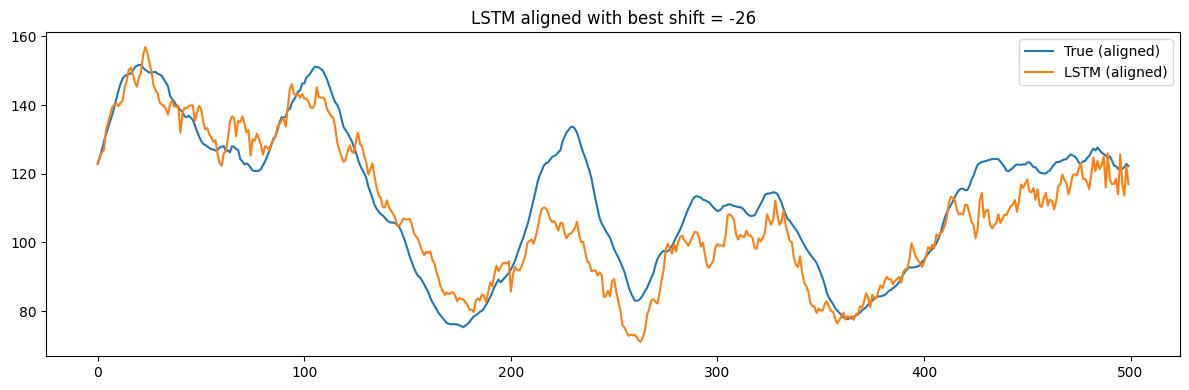

In [9]:
result_lstm = find_best_shift(y_test, y_pred_lstm, max_shift=60, metric="mae")
print("Best shift for LSTM:", result_lstm["best_shift"])
print(f"Best {result_lstm['metric'].upper()}: {result_lstm['best_score']:.4f}")
yt_lstm_aligned = result_lstm["y_true_aligned"]
yp_lstm_aligned = result_lstm["y_pred_aligned"]

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500  # sau khi align có thể ngắn hơn, nhớ check len()
plt.plot(yt_lstm_aligned[idx0:idx1], label="True (aligned)")
plt.plot(yp_lstm_aligned[idx0:idx1], label="LSTM (aligned)")
plt.legend()
plt.title(f"LSTM aligned with best shift = {result_lstm['best_shift']}")
plt.tight_layout()
plt.show()

Base dataframe after resample/interpolate:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327587 entries, 2024-05-22 12:13:00 to 2025-01-04 23:59:00
Freq: min
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          327587 non-null  float64
 1   TVOC         327587 non-null  float64
 2   PM10         327587 non-null  float64
 3   PM2.5        327587 non-null  float64
 4   eCO2         327587 non-null  float64
 5   CO           327587 non-null  float64
 6   Air Quality  327587 non-null  float64
 7   LDR          327587 non-null  float64
 8   O3           327587 non-null  float64
 9   Temp         327587 non-null  float64
 10  Hum          327587 non-null  float64
dtypes: float64(11)
memory usage: 30.0 MB
None
Feature dataframe with target_delta: (327557, 36)
X shape: (327512, 45, 35) | y_delta shape: (327512,)
Train: (229258, 45, 35) Val: (49127, 45, 35) Test: (49127, 45, 35)
=== Naive baseline (future

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 6.5955 - mae: 6.5955 - val_loss: 12.5016 - val_mae: 12.5016
Epoch 2/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5.6116 - mae: 5.6116 - val_loss: 14.5362 - val_mae: 14.5362
Epoch 3/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.8679 - mae: 4.8679 - val_loss: 14.2118 - val_mae: 14.2118
Epoch 4/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.3123 - mae: 4.3123 - val_loss: 15.5802 - val_mae: 15.5802
Epoch 5/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 3.8264 - mae: 3.8264 - val_loss: 15.8317 - val_mae: 15.8317
Epoch 6/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 3.4397 - mae: 3.4397 - val_loss: 16.0641 - val_mae: 16.0641
Epoch 7/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 3.1870 - mae: 3.1870 - val_loss: 15.9756 - val_mae: 15.9756
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

=== LSTM Model B (future 30-min avg PM2.5) ===
MAE  : 15.6050 µg/m³
RMSE : 20.2494 µg/m³
R²   : 0.6550
MBE  : -6.6

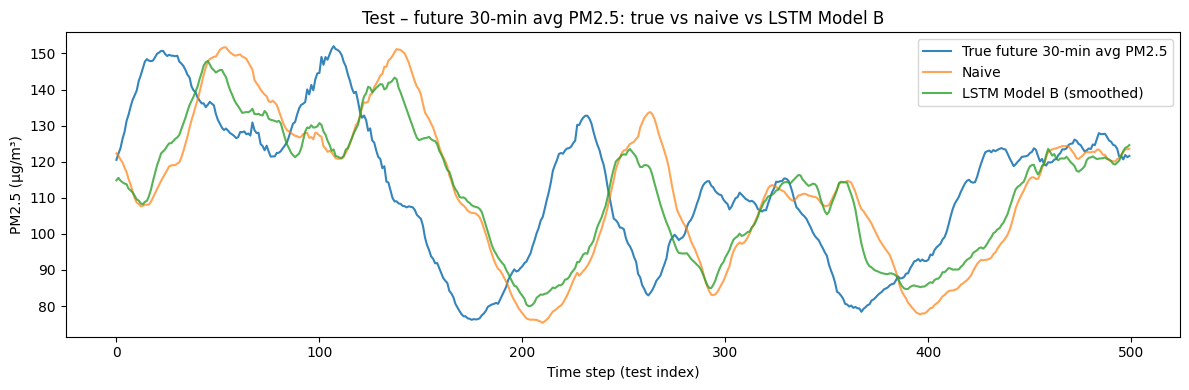

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. CONFIGURATION
# ============================================================

WINDOW_SIZE = 45          # giảm từ 60 -> 45 phút để phản ứng nhanh hơn
FUTURE_AVG_WINDOW = 30    # vẫn dự đoán average trong 30 phút tới

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15        # rest for test


# ============================================================
# 2. ASSUME df ALREADY LOADED
#    df is indexed by timestamp with columns incl. "PM2.5"
# ============================================================

df = df.sort_index()

# Make sure we have 1-min frequency and interpolate missing timestamps
df = df.resample("1min").mean()
df = df.interpolate(method="time")

print("Base dataframe after resample/interpolate:")
print(df.info())


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

feat = df.copy()

# ---------- PM2.5 features ----------
feat["pm25_ma5"]    = feat["PM2.5"].rolling(5,  min_periods=1).mean()
feat["pm25_ma10"]   = feat["PM2.5"].rolling(10, min_periods=1).mean()
feat["pm25_ma30"]   = feat["PM2.5"].rolling(30, min_periods=1).mean()
feat["pm25_std5"]   = feat["PM2.5"].rolling(5,  min_periods=1).std().fillna(0.0)
feat["pm25_diff1"]  = feat["PM2.5"].diff().fillna(0.0)

# Trend: ma10 - ma30
feat["pm25_trend"] = feat["pm25_ma10"] - feat["pm25_ma30"]

# NEW: Acceleration = diff(trend)
feat["pm25_accel"] = feat["pm25_trend"].diff().fillna(0.0)


# ---------- CO2 features ----------
if "CO2" in feat.columns:
    feat["co2_raw"]    = feat["CO2"]
    feat["co2_ma10"]   = feat["CO2"].rolling(10, min_periods=1).mean()
    feat["co2_ma30"]   = feat["CO2"].rolling(30, min_periods=1).mean()
    feat["co2_diff1"]  = feat["CO2"].diff().fillna(0.0)

    feat["co2_trend"]  = feat["co2_ma10"] - feat["co2_ma30"]
    feat["co2_accel"]  = feat["co2_trend"].diff().fillna(0.0)

# ---------- Temp & Hum ----------
if "Temp" in feat.columns:
    feat["temp_raw"]   = feat["Temp"]
    feat["temp_ma10"]  = feat["Temp"].rolling(10, min_periods=1).mean()

if "Hum" in feat.columns:
    feat["hum_raw"]    = feat["Hum"]
    feat["hum_ma10"]   = feat["Hum"].rolling(10, min_periods=1).mean()

# ---------- Other raw sensors (optional) ----------
for col in ["TVOC", "CO", "Air Quality", "O3", "LDR"]:
    if col in feat.columns:
        feat[col.lower().replace(" ", "_") + "_raw"] = feat[col]

# Time-of-day features (giữ lại vì đã giúp tăng R²)
feat["hour"] = feat.index.hour
feat["minute_of_day"] = feat.index.hour * 60 + feat.index.minute


# ============================================================
# 4. DEFINE TARGET – DELTA SO VỚI NAIVE
# ============================================================

# future_avg = average PM2.5 over next 30 min
pm25_future_avg30 = (
    df["PM2.5"]
    .rolling(FUTURE_AVG_WINDOW, min_periods=1)
    .mean()
    .shift(-FUTURE_AVG_WINDOW)
)

# current_avg = pm25_ma30 tại thời điểm hiện tại
current_avg = feat["pm25_ma30"]

# align index
pm25_future_avg30 = pm25_future_avg30.reindex(feat.index)

# target_delta = future_avg - current_avg
feat["target_delta"] = pm25_future_avg30 - current_avg

# Drop rows where target is NaN (near the end / early head)
feat = feat.dropna(subset=["target_delta"])
print("Feature dataframe with target_delta:", feat.shape)


# ============================================================
# 5. BUILD SUPERVISED WINDOWS
# ============================================================

def create_supervised_windows(dataframe, feature_cols, target_col, window_size):
    """
    X: past `window_size` steps of features
    y: target (delta) at current step
    """
    values = dataframe[feature_cols].values
    targets = dataframe[target_col].values

    X_list, y_list = [], []
    n_total = len(dataframe)

    for end_idx in range(window_size, n_total):
        start_idx = end_idx - window_size
        X_list.append(values[start_idx:end_idx])
        y_list.append(targets[end_idx])

    X = np.array(X_list)
    y = np.array(y_list)
    return X, y


feature_cols = [c for c in feat.columns if c != "target_delta"]

X, y_delta = create_supervised_windows(
    feat,
    feature_cols=feature_cols,
    target_col="target_delta",
    window_size=WINDOW_SIZE,
)

print("X shape:", X.shape, "| y_delta shape:", y_delta.shape)


# ============================================================
# 6. TRAIN/VAL/TEST SPLIT
# ============================================================

n_samples = len(X)
train_end = int(n_samples * TRAIN_RATIO)
val_end   = int(n_samples * (TRAIN_RATIO + VAL_RATIO))

X_train, y_train = X[:train_end], y_delta[:train_end]
X_val,   y_val   = X[train_end:val_end], y_delta[train_end:val_end]
X_test,  y_test  = X[val_end:], y_delta[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


# ============================================================
# 7. SCALE FEATURES
# ============================================================

num_features = X_train.shape[-1]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, num_features)
X_val_2d   = X_val.reshape(-1, num_features)
X_test_2d  = X_test.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)


# ============================================================
# 8. NAIVE BASELINE (delta = 0)
# ============================================================

# To evaluate trên "future avg", ta cần current_avg ở cuối mỗi window
pm25_ma30_col = "pm25_ma30"
pm25_ma30_idx = feature_cols.index(pm25_ma30_col)

current_avg_test = X_test[:, -1, pm25_ma30_idx]      # pm25_ma30 tại thời điểm dự báo
true_future_avg  = y_test + current_avg_test        # future_avg = delta + current_avg

y_pred_naive_future = current_avg_test              # naive: delta = 0

mae_naive  = mean_absolute_error(true_future_avg, y_pred_naive_future)
rmse_naive = np.sqrt(mean_squared_error(true_future_avg, y_pred_naive_future))
r2_naive   = r2_score(true_future_avg, y_pred_naive_future)

print("=== Naive baseline (future avg = current avg) ===")
print(f"MAE  : {mae_naive:.4f} µg/m³")
print(f"RMSE : {rmse_naive:.4f} µg/m³")
print(f"R²   : {r2_naive:.4f}")


# ============================================================
# 9. LSTM MODEL (PREDICT DELTA)
# ============================================================

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features)),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)   # output = delta (future_avg - current_avg)
])

optimizer = Adam(learning_rate=0.002)  # hơi cao hơn chút cho phản ứng nhanh

model.compile(
    loss="mae",          # vẫn dùng MAE cho robust
    optimizer=optimizer,
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# Evaluate on test set
# ------------------------------------------------------------
y_pred_delta = model.predict(X_test_scaled).ravel()

# reconstruct predicted future average
y_pred_future = current_avg_test + y_pred_delta

# smooth nhẹ cho đẹp
y_pred_future_smooth = (
    pd.Series(y_pred_future)
    .rolling(5, min_periods=1)
    .mean()
    .values
)

# Metrics cho forecast future avg
mae_lstm  = mean_absolute_error(true_future_avg, y_pred_future)
rmse_lstm = np.sqrt(mean_squared_error(true_future_avg, y_pred_future))
r2_lstm   = r2_score(true_future_avg, y_pred_future)
mbe_lstm  = np.mean(y_pred_future - true_future_avg)

print("\n=== LSTM Model B (future 30-min avg PM2.5) ===")
print(f"MAE  : {mae_lstm:.4f} µg/m³")
print(f"RMSE : {rmse_lstm:.4f} µg/m³")
print(f"R²   : {r2_lstm:.4f}")
print(f"MBE  : {mbe_lstm:.4f} µg/m³")

# Smoothed version
mae_lstm_s  = mean_absolute_error(true_future_avg, y_pred_future_smooth)
rmse_lstm_s = np.sqrt(mean_squared_error(true_future_avg, y_pred_future_smooth))
r2_lstm_s   = r2_score(true_future_avg, y_pred_future_smooth)
mbe_lstm_s  = np.mean(y_pred_future_smooth - true_future_avg)

print("\n=== LSTM Model B (SMOOTHED, rolling-5) ===")
print(f"MAE  : {mae_lstm_s:.4f} µg/m³")
print(f"RMSE : {rmse_lstm_s:.4f} µg/m³")
print(f"R²   : {r2_lstm_s:.4f}")
print(f"MBE  : {mbe_lstm_s:.4f} µg/m³")


# ============================================================
# 10. VISUALIZE
# ============================================================

plt.figure(figsize=(12, 4))
idx0, idx1 = 0, 500
plt.plot(true_future_avg[idx0:idx1], label="True future 30-min avg PM2.5", alpha=0.9)
plt.plot(y_pred_naive_future[idx0:idx1], label="Naive", alpha=0.7)
plt.plot(y_pred_future_smooth[idx0:idx1], label="LSTM Model B (smoothed)", alpha=0.8)
plt.legend()
plt.title("Test – future 30-min avg PM2.5: true vs naive vs LSTM Model B")
plt.xlabel("Time step (test index)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


Base dataframe after resample/interpolate:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327587 entries, 2024-05-22 12:13:00 to 2025-01-04 23:59:00
Freq: min
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CO2          327587 non-null  float64
 1   TVOC         327587 non-null  float64
 2   PM10         327587 non-null  float64
 3   PM2.5        327587 non-null  float64
 4   eCO2         327587 non-null  float64
 5   CO           327587 non-null  float64
 6   Air Quality  327587 non-null  float64
 7   LDR          327587 non-null  float64
 8   O3           327587 non-null  float64
 9   Temp         327587 non-null  float64
 10  Hum          327587 non-null  float64
dtypes: float64(11)
memory usage: 30.0 MB
None
feat_A shape: (327557, 16)


/tmp/ipykernel_47/1808262139.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feat_A["pm25_lag10"] = df["PM2.5"].shift(10).fillna(method="bfill")
/tmp/ipykernel_47/1808262139.py:67: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feat_A["pm25_lag20"] = df["PM2.5"].shift(20).fillna(method="bfill")


feat_B shape: (327557, 29)
Model A – X_A: (327497, 60, 15) | y_A: (327497,)
Model B – X_B: (327497, 60, 28) | y_B: (327497,)


I0000 00:00:1764230666.304822      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764230666.305388      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1764230672.146095     119 cuda_dnn.cc:529] Loaded cuDNN version 90300


896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 6030.4678 - mae: 63.1352 - val_loss: 846.6733 - val_mae: 21.0413
Epoch 2/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 163.0325 - mae: 7.8781 - val_loss: 401.1404 - val_mae: 14.6573
Epoch 3/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 104.9551 - mae: 6.5587 - val_loss: 326.3155 - val_mae: 13.5346
Epoch 4/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 89.8003 - mae: 6.2489 - val_loss: 320.0755 - val_mae: 13.5669
Epoch 5/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 80.2223 - mae: 6.0263 - val_loss: 305.4833 - val_mae: 13.3439
Epoch 6/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 73.3910 - mae: 5.8690 - val_loss: 318.0459 - val_mae: 13.5962
Epoch 7/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 64.2138 - mae: 5.5502 - val_loss: 368.9750 - val_mae: 14.4446
Epoch 8/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 57.9672 - mae: 5.2974 - val_loss: 388.8102 - val_mae: 14.9317
Epoch 9/50
896/896 ━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 4291.9839 - mae: 48.8646 - val_loss: 476.4050 - val_mae: 15.8685
Epoch 2/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 117.2335 - mae: 6.9258 - val_loss: 371.4708 - val_mae: 14.7013
Epoch 3/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 91.9738 - mae: 6.3461 - val_loss: 417.8142 - val_mae: 15.7374
Epoch 4/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 76.7505 - mae: 5.9727 - val_loss: 484.3840 - val_mae: 16.9370
Epoch 5/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 66.4423 - mae: 5.6361 - val_loss: 589.0137 - val_mae: 18.7420
Epoch 6/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 58.6465 - mae: 5.3462 - val_loss: 648.2908 - val_mae: 19.6251
Epoch 7/50
896/896 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 52.1785 - mae: 5.0274 - val_loss: 718.3377 - val_mae: 20.8181
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

=== MODEL B (early warning) ===
MAE  : 18.7130 µg/m³
RMSE : 24.0082 µg/m³
R²   : 0.5211
MBE  : -

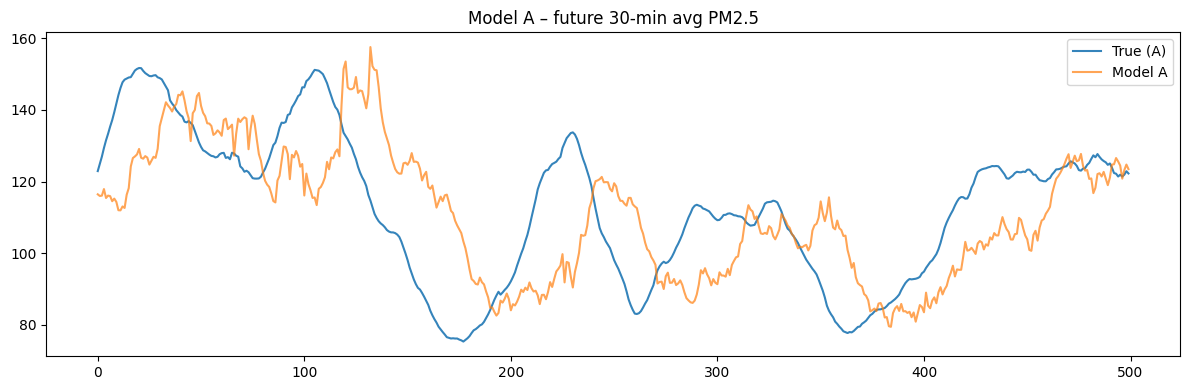

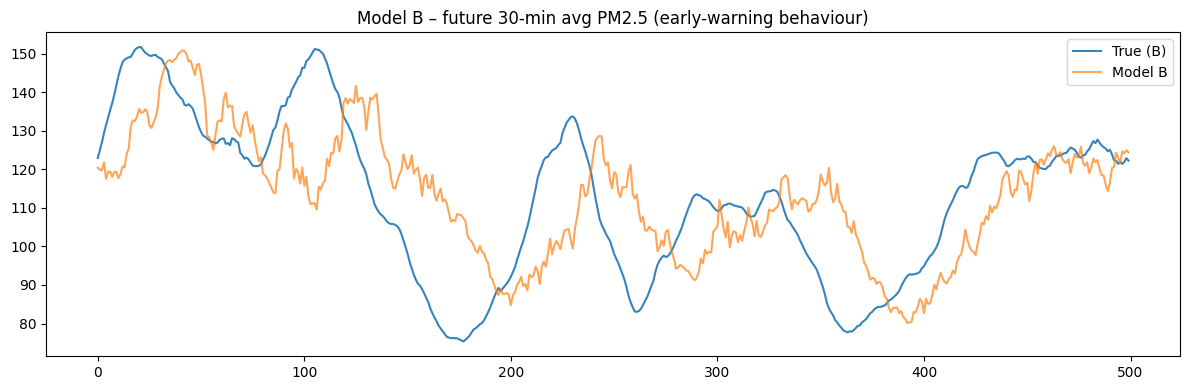

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. CONFIGURATION
# ============================================================

WINDOW_SIZE = 60          # use last 60 minutes as input
FUTURE_AVG_WINDOW = 30    # predict average over NEXT 30 minutes

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15        # rest for test


# ============================================================
# 2. COMMON PREPROCESSING
#    df is indexed by timestamp, has IAQ columns incl. "PM2.5"
# ============================================================

df = df.sort_index()

# 1-min frequency + interpolate missing
df = df.resample("1min").mean()
df = df.interpolate(method="time")

print("Base dataframe after resample/interpolate:")
print(df.info())


# ============================================================
# 3. TARGET: FUTURE 30-MINUTE AVERAGE PM2.5
# ============================================================

pm25_future_avg30 = (
    df["PM2.5"]
    .rolling(FUTURE_AVG_WINDOW, min_periods=1)
    .mean()
    .shift(-FUTURE_AVG_WINDOW)  # row at t → avg of t+1..t+30
)


# ============================================================
# 4. FEATURE ENGINEERING – MODEL A (trend follower, PM-based)
# ============================================================

feat_A = pd.DataFrame(index=df.index)

# --- PM2.5 core features ---
feat_A["pm25_raw"]   = df["PM2.5"]
feat_A["pm25_ma5"]   = df["PM2.5"].rolling(5,  min_periods=1).mean()
feat_A["pm25_ma10"]  = df["PM2.5"].rolling(10, min_periods=1).mean()
feat_A["pm25_ma30"]  = df["PM2.5"].rolling(30, min_periods=1).mean()
feat_A["pm25_std5"]  = df["PM2.5"].rolling(5,  min_periods=1).std().fillna(0.0)
feat_A["pm25_diff1"] = df["PM2.5"].diff().fillna(0.0)

# --- PM lags (giúp timing chính xác) ---
feat_A["pm25_lag10"] = df["PM2.5"].shift(10).fillna(method="bfill")
feat_A["pm25_lag20"] = df["PM2.5"].shift(20).fillna(method="bfill")

# --- PM ratio (PM2.5 vs PM10) nếu có PM10 ---
if "PM10" in df.columns:
    feat_A["pm10_raw"]  = df["PM10"]
    feat_A["pm10_ma10"] = df["PM10"].rolling(10, min_periods=1).mean()
    # tỉ lệ bụi mịn / bụi thô
    feat_A["pm_ratio_25_10"] = df["PM2.5"] / (df["PM10"] + 1e-6)

# --- Air Quality index nếu có (thường tương quan mạnh với PM) ---
if "Air Quality" in df.columns:
    feat_A["airq_raw"]  = df["Air Quality"]
    feat_A["airq_ma10"] = df["Air Quality"].rolling(10, min_periods=1).mean()

# --- time-of-day (chu kỳ ngày) ---
feat_A["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24.0)
feat_A["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24.0)

# add target
feat_A["target_pm25_avg30"] = pm25_future_avg30
feat_A = feat_A.dropna()
print("feat_A shape:", feat_A.shape)


# ============================================================
# 5. FEATURE ENGINEERING – MODEL B (early-warning, multi-sensor)
# ============================================================

feat_B = pd.DataFrame(index=df.index)

# --- PM2.5 rất ngắn hạn (để có chút info, nhưng không quá mạnh) ---
feat_B["pm25_ma5"]   = df["PM2.5"].rolling(5, min_periods=1).mean()
feat_B["pm25_diff1"] = df["PM2.5"].diff().fillna(0.0)

# --- CO2 & eCO2 (occupancy, hoạt động người) ---
if "CO2" in df.columns:
    feat_B["co2_raw"]   = df["CO2"]
    feat_B["co2_ma10"]  = df["CO2"].rolling(10, min_periods=1).mean()
    feat_B["co2_diff1"] = df["CO2"].diff().fillna(0.0)

if "eCO2" in df.columns:
    feat_B["eco2_raw"]   = df["eCO2"]
    feat_B["eco2_ma10"]  = df["eCO2"].rolling(10, min_periods=1).mean()
    feat_B["eco2_diff1"] = df["eCO2"].diff().fillna(0.0)

# --- TVOC (nấu ăn / hóa chất) ---
if "TVOC" in df.columns:
    feat_B["tvoc_raw"]   = df["TVOC"]
    feat_B["tvoc_ma10"]  = df["TVOC"].rolling(10, min_periods=1).mean()
    feat_B["tvoc_diff1"] = df["TVOC"].diff().fillna(0.0)

# --- Temp & Hum (môi trường, occupancy) ---
if "Temp" in df.columns:
    feat_B["temp_raw"]   = df["Temp"]
    feat_B["temp_ma10"]  = df["Temp"].rolling(10, min_periods=1).mean()
    feat_B["temp_diff1"] = df["Temp"].diff().fillna(0.0)

if "Hum" in df.columns:
    feat_B["hum_raw"]    = df["Hum"]
    feat_B["hum_ma10"]   = df["Hum"].rolling(10, min_periods=1).mean()
    feat_B["hum_diff1"]  = df["Hum"].diff().fillna(0.0)

# --- CO, O3, LDR (thêm leading clues) ---
if "CO" in df.columns:
    feat_B["co_raw"]   = df["CO"]
    feat_B["co_ma10"]  = df["CO"].rolling(10, min_periods=1).mean()
    feat_B["co_diff1"] = df["CO"].diff().fillna(0.0)

if "O3" in df.columns:
    feat_B["o3_raw"]   = df["O3"]
    feat_B["o3_ma10"]  = df["O3"].rolling(10, min_periods=1).mean()
    feat_B["o3_diff1"] = df["O3"].diff().fillna(0.0)

if "LDR" in df.columns:
    feat_B["ldr_raw"]   = df["LDR"]
    feat_B["ldr_ma10"]  = df["LDR"].rolling(10, min_periods=1).mean()
    feat_B["ldr_diff1"] = df["LDR"].diff().fillna(0.0)

# --- time-of-day ---
feat_B["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24.0)
feat_B["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24.0)

# (quan trọng) KHÔNG dùng PM10, Air Quality trong B – để tránh “ăn theo” PM2.5 trực tiếp

feat_B["target_pm25_avg30"] = pm25_future_avg30
feat_B = feat_B.dropna()
print("feat_B shape:", feat_B.shape)


# ============================================================
# 6. COMMON FUNCTION: BUILD WINDOWS
# ============================================================

def create_supervised_windows(dataframe, feature_cols, target_col, window_size):
    values = dataframe[feature_cols].values
    targets = dataframe[target_col].values

    X_list, y_list = [], []
    n_total = len(dataframe)

    for end_idx in range(window_size, n_total):
        start_idx = end_idx - window_size
        X_list.append(values[start_idx:end_idx])
        y_list.append(targets[end_idx])

    X = np.array(X_list)
    y = np.array(y_list)
    return X, y


# ============================================================
# 7. BUILD DATA – MODEL A
# ============================================================

feature_cols_A = [c for c in feat_A.columns if c != "target_pm25_avg30"]
X_A, y_A = create_supervised_windows(
    feat_A,
    feature_cols=feature_cols_A,
    target_col="target_pm25_avg30",
    window_size=WINDOW_SIZE,
)
print("Model A – X_A:", X_A.shape, "| y_A:", y_A.shape)

n_samples_A = len(X_A)
train_end_A = int(n_samples_A * TRAIN_RATIO)
val_end_A   = int(n_samples_A * (TRAIN_RATIO + VAL_RATIO))

X_train_A, y_train_A = X_A[:train_end_A], y_A[:train_end_A]
X_val_A,   y_val_A   = X_A[train_end_A:val_end_A], y_A[train_end_A:val_end_A]
X_test_A,  y_test_A  = X_A[val_end_A:], y_A[val_end_A:]

num_features_A = X_train_A.shape[-1]
scaler_A = StandardScaler()
X_train_A_2d = X_train_A.reshape(-1, num_features_A)
X_val_A_2d   = X_val_A.reshape(-1, num_features_A)
X_test_A_2d  = X_test_A.reshape(-1, num_features_A)

X_train_A_scaled = scaler_A.fit_transform(X_train_A_2d).reshape(X_train_A.shape)
X_val_A_scaled   = scaler_A.transform(X_val_A_2d).reshape(X_val_A.shape)
X_test_A_scaled  = scaler_A.transform(X_test_A_2d).reshape(X_test_A.shape)


# ============================================================
# 8. BUILD DATA – MODEL B
# ============================================================

feature_cols_B = [c for c in feat_B.columns if c != "target_pm25_avg30"]
X_B, y_B = create_supervised_windows(
    feat_B,
    feature_cols=feature_cols_B,
    target_col="target_pm25_avg30",
    window_size=WINDOW_SIZE,
)
print("Model B – X_B:", X_B.shape, "| y_B:", y_B.shape)

n_samples_B = len(X_B)
train_end_B = int(n_samples_B * TRAIN_RATIO)
val_end_B   = int(n_samples_B * (TRAIN_RATIO + VAL_RATIO))

X_train_B, y_train_B = X_B[:train_end_B], y_B[:train_end_B]
X_val_B,   y_val_B   = X_B[train_end_B:val_end_B], y_B[train_end_B:val_end_B]
X_test_B,  y_test_B  = X_B[val_end_B:], y_B[val_end_B:]

num_features_B = X_train_B.shape[-1]
scaler_B = StandardScaler()
X_train_B_2d = X_train_B.reshape(-1, num_features_B)
X_val_B_2d   = X_val_B.reshape(-1, num_features_B)
X_test_B_2d  = X_test_B.reshape(-1, num_features_B)

X_train_B_scaled = scaler_B.fit_transform(X_train_B_2d).reshape(X_train_B.shape)
X_val_B_scaled   = scaler_B.transform(X_val_B_2d).reshape(X_val_B.shape)
X_test_B_scaled  = scaler_B.transform(X_test_B_2d).reshape(X_test_B.shape)


# ============================================================
# 9. HELPER: find_best_shift (để đo lag)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def find_best_shift(y_true, y_pred, max_shift=60, metric="mae"):
    assert len(y_true) == len(y_pred)

    best_shift = 0
    best_score = np.inf
    for shift in range(-max_shift, max_shift + 1):
        if shift > 0:
            yt = y_true[shift:]
            yp = y_pred[:-shift]
        elif shift < 0:
            s = -shift
            yt = y_true[:-s]
            yp = y_pred[s:]
        else:
            yt = y_true
            yp = y_pred

        if metric == "mae":
            score = mean_absolute_error(yt, yp)
        else:
            score = np.sqrt(mean_squared_error(yt, yp))

        if score < best_score:
            best_score = score
            best_shift = shift

    return best_shift, best_score


# ============================================================
# 10. TRAIN LSTM – MODEL A
# ============================================================

model_A = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features_A)),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

model_A.compile(loss="mse", optimizer="adam", metrics=["mae"])
early_stop_A = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_A = model_A.fit(
    X_train_A_scaled, y_train_A,
    validation_data=(X_val_A_scaled, y_val_A),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop_A],
    verbose=1,
)

y_pred_A = model_A.predict(X_test_A_scaled).ravel()

mae_A  = mean_absolute_error(y_test_A, y_pred_A)
rmse_A = np.sqrt(mean_squared_error(y_test_A, y_pred_A))
r2_A   = r2_score(y_test_A, y_pred_A)
mbe_A  = np.mean(y_pred_A - y_test_A)

print("\n=== MODEL A (trend follower) ===")
print(f"MAE  : {mae_A:.4f} µg/m³")
print(f"RMSE : {rmse_A:.4f} µg/m³")
print(f"R²   : {r2_A:.4f}")
print(f"MBE  : {mbe_A:.4f} µg/m³")

best_shift_A, best_mae_shift_A = find_best_shift(y_test_A, y_pred_A, max_shift=60, metric="mae")
print(f"Best shift A: {best_shift_A} steps | MAE_shift: {best_mae_shift_A:.4f}")


# ============================================================
# 11. TRAIN LSTM – MODEL B
# ============================================================

model_B = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features_B)),
    LSTM(32),
    Dense(32, activation="relu"),
    Dense(1)
])

model_B.compile(loss="mse", optimizer="adam", metrics=["mae"])
early_stop_B = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_B = model_B.fit(
    X_train_B_scaled, y_train_B,
    validation_data=(X_val_B_scaled, y_val_B),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop_B],
    verbose=1,
)

y_pred_B = model_B.predict(X_test_B_scaled).ravel()

mae_B  = mean_absolute_error(y_test_B, y_pred_B)
rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_B))
r2_B   = r2_score(y_test_B, y_pred_B)
mbe_B  = np.mean(y_pred_B - y_test_B)

print("\n=== MODEL B (early warning) ===")
print(f"MAE  : {mae_B:.4f} µg/m³")
print(f"RMSE : {rmse_B:.4f} µg/m³")
print(f"R²   : {r2_B:.4f}")
print(f"MBE  : {mbe_B:.4f} µg/m³")

best_shift_B, best_mae_shift_B = find_best_shift(y_test_B, y_pred_B, max_shift=60, metric="mae")
print(f"Best shift B: {best_shift_B} steps | MAE_shift: {best_mae_shift_B:.4f}")


# ============================================================
# 12. QUICK VISUALIZATION FOR A & B (no shift)
# ============================================================

idx0, idx1 = 0, 500

plt.figure(figsize=(12, 4))
plt.plot(y_test_A[idx0:idx1], label="True (A)", alpha=0.9)
plt.plot(y_pred_A[idx0:idx1], label="Model A", alpha=0.7)
plt.title("Model A – future 30-min avg PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(y_test_B[idx0:idx1], label="True (B)", alpha=0.9)
plt.plot(y_pred_B[idx0:idx1], label="Model B", alpha=0.7)
plt.title("Model B – future 30-min avg PM2.5 (early-warning behaviour)")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Conv1D, BatchNormalization, Activation,
    Add, Input, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv1D, BatchNormalization, Activation, Dropout,
    Add, GlobalAveragePooling1D, Dense
)


In [21]:
# ============================================================
# 3. FEATURE ENGINEERING (MULTI-SENSOR FOR TCN / TF)
# ============================================================

feat = pd.DataFrame(index=df.index)

pm25 = df["PM2.5"]

# --- PM2.5 core features ---
feat["pm25_raw"]       = pm25
feat["pm25_smooth5"]   = pm25.rolling(5,  min_periods=1).mean()
feat["pm25_smooth10"]  = pm25.rolling(10, min_periods=1).mean()
feat["pm25_ma30"]      = pm25.rolling(30, min_periods=1).mean()
feat["pm25_std5"]      = pm25.rolling(5,  min_periods=1).std().fillna(0.0)

feat["pm25_trend10"]   = feat["pm25_smooth10"].diff().fillna(0.0)
feat["pm25_trend30"]   = feat["pm25_ma30"].diff().fillna(0.0)

feat["pm25_lag10"]     = feat["pm25_smooth10"].shift(10).bfill()
feat["pm25_lag20"]     = feat["pm25_smooth10"].shift(20).bfill()

# time-of-day (ngày đêm)
feat["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24.0)
feat["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24.0)

# --- Multi-sensor features (raw + ma5) ---
sensor_cols = {
    "co2":        "CO2",
    "tvoc":       "TVOC",
    "pm10":       "PM10",
    "eco2":       "eCO2",
    "co":         "CO",
    "airq":       "Air Quality",
    "o3":         "O3",
    "temp":       "Temp",
    "hum":        "Hum",
    # "ldr":      "LDR",  # cái này corr yếu, có thể bỏ
}

for prefix, colname in sensor_cols.items():
    if colname not in df.columns:
        continue
    s = df[colname]
    feat[f"{prefix}_raw"] = s
    feat[f"{prefix}_ma5"] = s.rolling(5, min_periods=1).mean()


In [17]:
feature_cols = [c for c in feat.columns if c != "target_pm25_avg30"]


In [22]:
# ============================================================
# 9A. TCN MODEL FOR FUTURE 30-MIN AVERAGE (MODEL A – TCN)
# ============================================================

# ============================================================
# 9A. IMPROVED TCN MODEL
# ============================================================

def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout_rate=0.1):
    # 1st conv
    y = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation_rate)(x)
    y = BatchNormalization()(y)
    y = Activation("relu")(y)
    y = Dropout(dropout_rate)(y)

    # 2nd conv
    y = Conv1D(filters, kernel_size,
               padding="causal",
               dilation_rate=dilation_rate)(y)
    y = BatchNormalization()(y)

    # residual projection nếu số kênh khác
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1, padding="same")(x)

    out = Add()([x, y])
    out = Activation("relu")(out)
    return out

inputs = tf.keras.Input(shape=(WINDOW_SIZE, num_features))

x = inputs
# nhiều block với dilation mở rộng → receptive field rộng nhưng không quá deep
for d in [1, 2, 4, 8]:
    x = tcn_block(x, filters=64, kernel_size=3, dilation_rate=d, dropout_rate=0.1)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)

model_tcn = Model(inputs, outputs)

# dùng Huber loss để bớt bóp đỉnh
model_tcn.compile(
    loss=tf.keras.losses.Huber(delta=5.0),
    optimizer="adam",
    metrics=["mae"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tcn = model_tcn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

y_pred_tcn = model_tcn.predict(X_test_scaled).ravel()

mae_tcn  = mean_absolute_error(y_test, y_pred_tcn)
rmse_tcn = np.sqrt(mean_squared_error(y_test, y_pred_tcn))
r2_tcn   = r2_score(y_test, y_pred_tcn)
mbe_tcn  = np.mean(y_pred_tcn - y_test)

print("\n=== Improved TCN Model ===")
print(f"MAE  : {mae_tcn:.4f} µg/m³")
print(f"RMSE : {rmse_tcn:.4f} µg/m³")
print(f"R²   : {r2_tcn:.4f}")
print(f"MBE  : {mbe_tcn:.4f} µg/m³")



Epoch 1/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - loss: 109.0997 - mae: 23.9555 - val_loss: 58.7882 - val_mae: 14.0401
Epoch 2/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 38.1849 - mae: 9.6188 - val_loss: 55.1584 - val_mae: 13.3093
Epoch 3/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36.9981 - mae: 9.3457 - val_loss: 56.1334 - val_mae: 13.5020
Epoch 4/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36.5485 - mae: 9.2467 - val_loss: 55.0973 - val_mae: 13.2955
Epoch 5/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 35.5600 - mae: 9.0334 - val_loss: 55.1926 - val_mae: 13.3146
Epoch 6/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 35.5413 - mae: 9.0305 - val_loss: 53.9084 - val_mae: 13.0643
Epoch 7/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 34.6940 - mae: 8.8582 - val_loss: 58.3588 - val_mae: 13.9642
Epoch 8/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 33.9552 - mae: 8.7053 - val_loss: 57.1417 - val_mae: 13.7268
Epoch 9/60
896

In [15]:
from tensorflow.keras.layers import (
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)


In [23]:
# ============================================================
# 9B. IMPROVED TRANSFORMER MODEL
# ============================================================

def transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout_rate=0.1):
    # Self-attention + residual
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    x = Add()([x, attn_output])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed-forward + residual
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dropout(dropout_rate)(ffn)
    ffn = Dense(x.shape[-1])(ffn)

    x = Add()([x, ffn])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x

inputs_tf = tf.keras.Input(shape=(WINDOW_SIZE, num_features))

# LayerNorm đầu vào cho ổn định
x = LayerNormalization(epsilon=1e-6)(inputs_tf)

# 2 encoder blocks
x = transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout_rate=0.1)
x = transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout_rate=0.1)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
outputs_tf = Dense(1)(x)

model_tf = Model(inputs_tf, outputs_tf)

model_tf.compile(
    loss=tf.keras.losses.Huber(delta=5.0),
    optimizer="adam",
    metrics=["mae"]
)

early_stop_tf = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history_tf = model_tf.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[early_stop_tf],
    verbose=1
)

y_pred_tf = model_tf.predict(X_test_scaled).ravel()

mae_tf  = mean_absolute_error(y_test, y_pred_tf)
rmse_tf = np.sqrt(mean_squared_error(y_test, y_pred_tf))
r2_tf   = r2_score(y_test, y_pred_tf)
mbe_tf  = np.mean(y_pred_tf - y_test)

print("\n=== Improved Transformer Model ===")
print(f"MAE  : {mae_tf:.4f} µg/m³")
print(f"RMSE : {rmse_tf:.4f} µg/m³")
print(f"R²   : {r2_tf:.4f}")
print(f"MBE  : {mbe_tf:.4f} µg/m³")



Epoch 1/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - loss: 202.6203 - mae: 42.7509 - val_loss: 62.5690 - val_mae: 14.8064
Epoch 2/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 38.5005 - mae: 9.7223 - val_loss: 60.4941 - val_mae: 14.3936
Epoch 3/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 36.5811 - mae: 9.3015 - val_loss: 64.0094 - val_mae: 15.0980
Epoch 4/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 36.1132 - mae: 9.2047 - val_loss: 61.5257 - val_mae: 14.5958
Epoch 5/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 34.9298 - mae: 8.9523 - val_loss: 61.2356 - val_mae: 14.5387
Epoch 6/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 34.9424 - mae: 8.9621 - val_loss: 62.1617 - val_mae: 14.7230
Epoch 7/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 34.0865 - mae: 8.7870 - val_loss: 60.3977 - val_mae: 14.3802
Epoch 8/60
896/896 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 34.0188 - mae: 8.7603 - val_loss: 60.3396 - val_mae: 14.3640
Epoch 9/60
896

In [ ]:
idx0, idx1 = 0, 500
plt.figure(figsize=(12, 4))
plt.plot(y_test[idx0:idx1], label="True", alpha=0.9)
plt.plot(y_pred_tcn[idx0:idx1], label="TCN", alpha=0.7)
plt.plot(y_pred_tf[idx0:idx1], label="Transformer", alpha=0.7)
plt.legend(); plt.tight_layout(); plt.show()
